In [7]:
# ============================================================
# CELL PURPOSE: Import libraries and load raw merged dataset
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path (same as before)
DATA_PATH = "/Users/sanjana/Desktop/Hype-Predictor/Data"

# Load raw merged data
df = pd.read_csv(f"{DATA_PATH}/raw_merged.csv")

# Preview
print(df.head())
print("\nShape:", df.shape)

           product  trends_score  score  comments  reddit_score  view_count  \
0    Air Jordan 11     33.114504   3284      1111          4395     2879391   
1  Nvidia RTX 5090      9.385496  14788      6533         21321    14985368   
2    Owala FreeSip     11.656489  23348      3323         26671     1839405   
3          PS5 Pro     10.225191  32748     34042         66790     3563703   
4        iPhone 17      4.362595  25906      6491         32397     8444558   

   like_count  comment_count  youtube_score  news_score  
0      111771           3101        2994263          96  
1      526589          30091       15542048         100  
2       22316           1408        1863129          27  
3       64684          14669        3643056          98  
4      221355           8938        8674851          99  

Shape: (5, 10)


       trends_score  reddit_score  youtube_score  news_score
count      5.000000      5.000000   5.000000e+00    5.000000
mean      13.748855  30314.800000   6.543469e+06   84.000000
std       11.168744  22917.119806   5.666393e+06   31.898276
min        4.362595   4395.000000   1.863129e+06   27.000000
25%        9.385496  21321.000000   2.994263e+06   96.000000
50%       10.225191  26671.000000   3.643056e+06   98.000000
75%       11.656489  32397.000000   8.674851e+06   99.000000
max       33.114504  66790.000000   1.554205e+07  100.000000


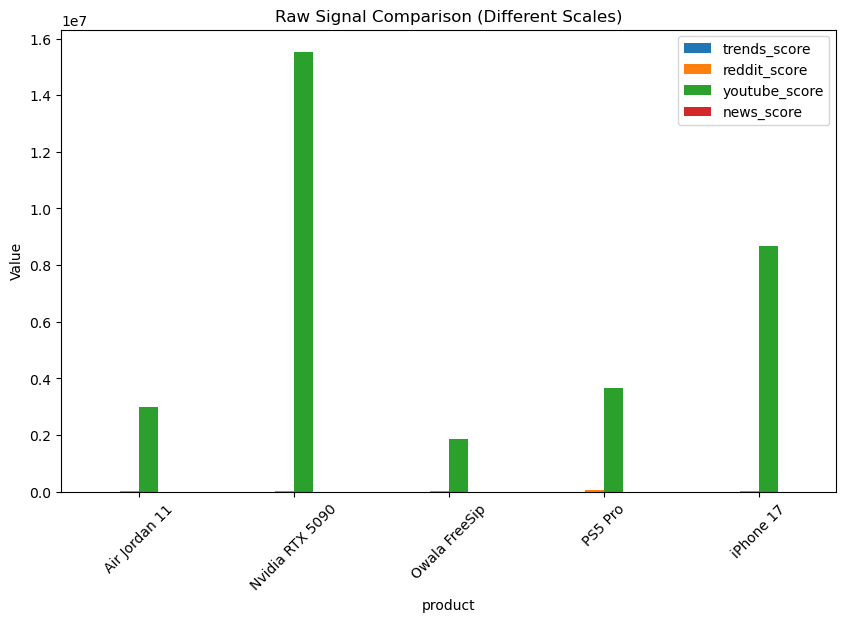

In [9]:
# ============================================================
# CELL PURPOSE: Compare scale of different signals
# ============================================================

# Select key signals
cols = ["trends_score", "reddit_score", "youtube_score", "news_score"]

# Basic statistics
print(df[cols].describe())

# Plot comparison
df.set_index("product")[cols].plot(kind="bar", figsize=(10,6))

plt.title("Raw Signal Comparison (Different Scales)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#The signals exist on completely different scales, with YouTube dominating by several orders of magnitude. 
#This makes direct comparison or aggregation invalid.
#The bar chart shows that YouTube signals dominate all other sources due to scale differences, making raw aggregation unreliable.
#Without normalization, the hype score would essentially become a YouTube popularity metric rather than a multi-source signal.

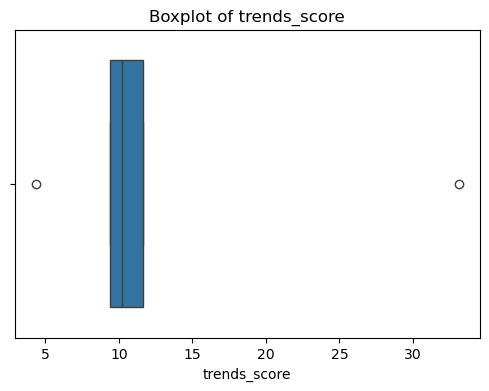

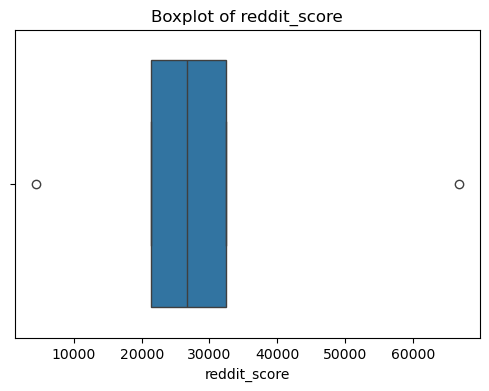

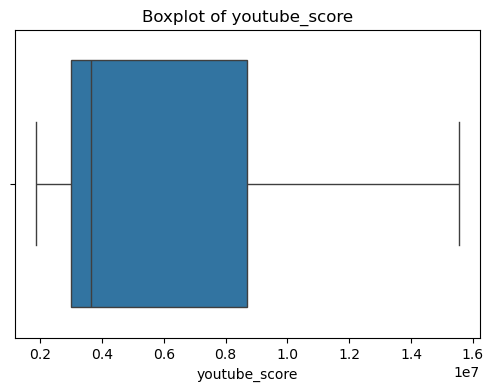

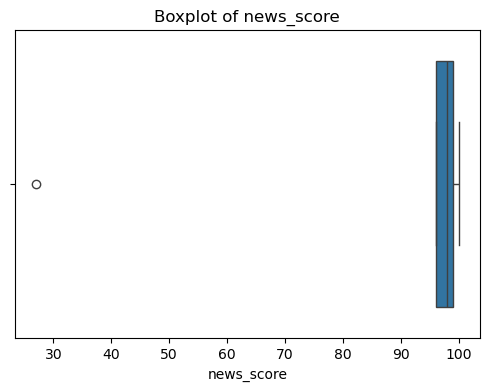

In [11]:
# ============================================================
# CELL PURPOSE: Detect outliers across signals
# ============================================================

cols = ["trends_score", "reddit_score", "youtube_score", "news_score"]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#1. Reddit (most important) clearly have a high-end outlier That’s likely PS5 Pro (~66K)
#Also:Owala is unexpectedly high compared to its category👉 This confirms:Reddit signal is skewed and noisy
#2. YouTube Very wide spread One extreme high value: 👉 Nvidia RTX 5090 (~15M)
#👉 This shows:YouTube has dominance + heavy skew
#3. News Tight cluster (~96–100) One low outlier:👉 Owala (~27)
#👉 Insight:News is compressed → low differentiation
#4. Trends One high outlier:👉 Air Jordan (~33)
#👉 Insight:Trends vary but not dramatically

#Boxplots reveal significant skewness and outliers across signals.
#Reddit and YouTube show extreme values for certain products, while News data is tightly clustered, limiting its discriminative power.”

               trends_score  reddit_score  youtube_score  news_score
trends_score       1.000000     -0.589123      -0.426589    0.064358
reddit_score      -0.589123      1.000000      -0.140996    0.100765
youtube_score     -0.426589     -0.140996       1.000000    0.497282
news_score         0.064358      0.100765       0.497282    1.000000


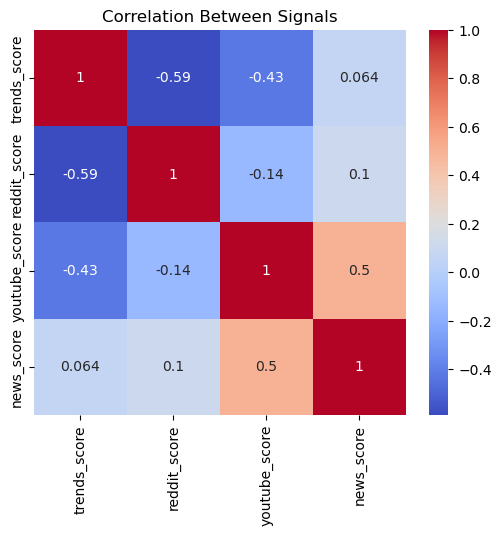

In [13]:
# ============================================================
# CELL PURPOSE: Correlation between signals
# ============================================================

cols = ["trends_score", "reddit_score", "youtube_score", "news_score"]

corr = df[cols].corr()

print(corr)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Signals")
plt.show()

In [ ]:
"""🔍 "Key Observations
1. ❗ Trends vs Reddit → -0.59 (negative)
When Trends is high, Reddit tends to be low
👉 Meaning:
These sources are capturing different types of hype
2. ❗ Trends vs YouTube → -0.43
Again, not aligned
👉 Meaning:
Search interest ≠ video popularity
3. ❗ Reddit vs YouTube → -0.14 (very weak)
Almost no relationship
👉 Meaning:
Social discussion ≠ content consumption
4. ✅ YouTube vs News → +0.50 (moderate)
Only meaningful correlation
👉 Meaning:
Media coverage and video content are somewhat aligned
5. ⚠️ News vs others → ~0
Very weak relationships
👉 Meaning:
News is not a strong differentiator
🧠 The BIG Insight (this is your core argument)
You can now confidently say:
“Correlation analysis shows that signals are weakly correlated or even negatively correlated, indicating that each source captures a distinct dimension of product hype.”
🔥 Even stronger version (use this in presentation)
“The lack of strong correlation across sources confirms that hype is multi-dimensional. No single source can fully represent product popularity.” """

In [17]:
# ============================================================
# CELL PURPOSE: Load Reddit data for noise inspection
# ============================================================

reddit = pd.read_csv(f"{DATA_PATH}/reddit_data.csv")

print(reddit.head())
# ============================================================
# CELL PURPOSE: Show sample Reddit posts (noise inspection)
# ============================================================

# Show random Reddit posts
print(reddit.sample(5)[["product", "subreddit", "title"]])

         product    subreddit  \
0  Owala FreeSip  HydroHomies   
1  Owala FreeSip  HydroHomies   
2  Owala FreeSip  HydroHomies   
3        PS5 Pro          PS5   
4      iPhone 17        apple   

                                               title  score  comments  \
0                              Henry is a real Homie   7855        45   
1              I stumbled upon this sub's theme song   3655       137   
2             My new emotional support water bottle!   3599       181   
3  Starfield PS5 players demand refunds, reportin...   3242       631   
4  FBI Extracts Suspect’s Deleted Signal Messages...   2755       390   

   upvote_ratio  
0          0.98  
1          0.98  
2          0.93  
3          0.87  
4          0.98  
             product    subreddit  \
486    Owala FreeSip  AmazonFinds   
375  Nvidia RTX 5090     buildapc   
560    Air Jordan 11         Nike   
254    Air Jordan 11         Nike   
582          PS5 Pro  playstation   

                               

In [ ]:
#Manual inspection of Reddit posts reveals significant noise, including irrelevant discussions, community chatter, and keyword-based 
#mismatches, indicating that raw Reddit data does not reliably represent product hype.